# Retrieving df from Zenodo / BigQuery storage

In [ ]:
%pip install -r requirements.txt

In [ ]:
import pandas as pd

# Download df_analysis.parquet from Zenodo:
# https://doi.org/10.5281/zenodo.20370476
# and place it in data/
df = pd.read_parquet("data/df_analysis.parquet")
print(df.shape)
df.head()

In [ ]:
# Optional: re-extract from BigQuery instead of reading the Zenodo file.
# Requires a GCP project with billing enabled and the query from
# Appendix A of the thesis (or query.sql in this repo).
#
# PROJECT_ID = "YOUR-PROJECT-ID"
# client = bigquery.Client(project=PROJECT_ID)
# job = client.query(open("query.sql").read())
# df = job.to_dataframe()

In [ ]:
# Optional: re-extract from BigQuery instead of reading the Zenodo file.
# from google.cloud import bigquery

# PROJECT_ID = #redacted
# TABLE_REF  = #redacted

# client = bigquery.Client(project=PROJECT_ID)

# df = client.list_rows(TABLE_REF).to_dataframe(
#     create_bqstorage_client=True
# )

# print(df.shape)
# df.head()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


(7590599, 23)


,repo_id,repo_name,month,total_commits,ai_assisted_commits,ai_assisted_proportion,unique_human_contributors,stars_gained,issues_opened,issues_closed,...,external_backlog_growth,closure_rate,external_closure_rate,any_closure,window_total_commits,window_unique_contributors,window_external_issues_opened_total,is_fork,cumulative_open_issues,cumulative_external_open_issues
0,249,cristibalan/braid,2024-10,2,0,0.0,1,0,1,0,...,1,0.0,0.0,0,6,2,13,False,1,1
1,249,cristibalan/braid,2024-11,4,0,0.0,2,1,0,0,...,0,NaN,NaN,0,6,2,13,False,1,1
2,912,collectiveidea/awesome_nested_set,2024-10,1,0,0.0,1,7,0,0,...,0,NaN,NaN,0,5,2,5,False,0,0
3,912,collectiveidea/awesome_nested_set,2024-11,4,0,0.0,1,4,2,1,...,1,0.5,0.5,1,5,2,5,False,1,1
4,2019,jruby/warbler,2024-10,3,0,0.0,1,2,0,0,...,0,NaN,NaN,0,46,4,6,False,0,0


In [2]:
print("Columns:", df.columns.tolist())

print("Rows per repo (top 5):")
print(df.groupby("repo_id").size().describe())
print("\nAI exposure check:")
print(f"  Cells with AI: {(df['ai_assisted_commits'] > 0).sum():,}")
print(f"  Total cells:   {len(df):,}")
print(f"  Pct:           {100 * (df['ai_assisted_commits'] > 0).mean():.2f}%")

Columns: ['repo_id', 'repo_name', 'month', 'total_commits', 'ai_assisted_commits', 'ai_assisted_proportion', 'unique_human_contributors', 'stars_gained', 'issues_opened', 'issues_closed', 'external_issues_opened', 'external_issues_closed', 'backlog_growth', 'external_backlog_growth', 'closure_rate', 'external_closure_rate', 'any_closure', 'window_total_commits', 'window_unique_contributors', 'window_external_issues_opened_total', 'is_fork', 'cumulative_open_issues', 'cumulative_external_open_issues']
Rows per repo (top 5):
count    2.412338e+06
mean     3.146574e+00
std      2.810431e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      1.090000e+02
dtype: float64

AI exposure check:
  Cells with AI: 71,798
  Total cells:   7,590,599
  Pct:           0.95%


# Data Cleaning

In [ ]:
print(f"Raw: {len(df):,} cells, {df['repo_id'].nunique():,} repos")
print(f"Months covered: {df['month'].min()} → {df['month'].max()}")
print(f"Fork share: {df['is_fork'].mean():.2%}")
print(f"AI rate (raw, cell-level): {(df['ai_assisted_commits'] > 0).mean():.2%}")

Raw: 7,590,599 cells, 2,412,338 repos
Months covered: 2024-09 → 2025-09
Fork share: 7.12%
AI rate (raw, cell-level): 0.95%


In [34]:
df_clean = df[~df['is_fork']].copy()
print(f"After fork drop: {len(df_clean):,} cells, {df_clean['repo_id'].nunique():,} repos")

After fork drop: 7,050,344 cells, 2,195,285 repos


In [ ]:
ISSUE_FLOOR = 15
df_clean = df_clean[df_clean['window_external_issues_opened_total'] >= ISSUE_FLOOR]
print(f"After issue-activity filter (≥{ISSUE_FLOOR}): "
    f"{len(df_clean):,} cells, {df_clean['repo_id'].nunique():,} repos")

After issue-activity filter (≥15): 518,966 cells, 65,583 repos


In [36]:
RENAME_MAX = 4
name_count = df_clean.groupby('repo_id')['repo_name'].nunique()
clean_ids = name_count[name_count <= RENAME_MAX].index
dropped = (name_count > RENAME_MAX).sum()
df_clean = df_clean[df_clean['repo_id'].isin(clean_ids)]
print(f"Dropped {dropped:,} high-rename repos. "
    f"Remaining: {len(df_clean):,} cells, {df_clean['repo_id'].nunique():,} repos")

Dropped 62 high-rename repos. Remaining: 518,228 cells, 65,521 repos


In [122]:
df.head()

,repo_id,month,repo_name,total_commits,ai_assisted_commits,unique_human_contributors,stars_gained,issues_opened,issues_closed,external_issues_opened,...,ai_assisted_proportion_lag1,ai_assisted_proportion_lag2,has_ai,backlog_growth_w,external_backlog_growth_w,closure_rate_w,external_closure_rate_w,log_total_commits,log_stars_gained,ai_bucket
0,3314,2024-09,spree/spree,96,0,3,59,0,0,0,...,NaN,NaN,False,0.0,0.0,NaN,NaN,4.574711,4.094345,0%
1,3314,2024-10,spree/spree,78,0,3,160,2,3,2,...,0.0,NaN,False,-1.0,-1.0,1.5,1.5,4.369448,5.081404,0%
2,3314,2024-11,spree/spree,164,0,4,85,2,0,2,...,0.0,0.0,False,2.0,2.0,0.0,0.0,5.105945,4.454347,0%
3,3314,2024-12,spree/spree,56,0,3,73,2,1,2,...,0.0,0.0,False,1.0,1.0,0.5,0.5,4.043051,4.304065,0%
4,3314,2025-01,spree/spree,428,0,4,978,4,4,4,...,0.0,0.0,False,0.0,0.0,1.0,1.0,6.061457,6.886532,0%


In [41]:
top_open_months = (
    df_clean.nlargest(20, 'issues_opened')
    [['repo_id', 'repo_name', 'month', 'issues_opened', 'issues_closed']]
)
print(top_open_months.to_string())

           repo_id                                   repo_name    month  issues_opened  issues_closed
1631        206483                                apache/maven  2025-07           5278           1008
1439432   41881900                            microsoft/vscode  2025-07           2752           2168
1439433   41881900                            microsoft/vscode  2025-08           2210           1847
247527     8016431                         pegasus-isi/pegasus  2024-12           1952           1834
1071985   38052817                    kieker-monitoring/kieker  2024-11           1930           1354
1439434   41881900                            microsoft/vscode  2025-09           1886           1592
2669969   96556718                                    FDio/vpp  2025-01           1876           1113
794729    27442967                           fastlane/fastlane  2024-10           1826            133
1396950  629635341            microsoft/vscode-copilot-release  2025-05           

In [ ]:
auto_patterns = ['upptime', 'offensive-vk/', 'Picadailys/support',
                'DaoCloud/public-image-mirror', 'printerdrivers/',
                'strobes-test/']
mask_auto = df_clean['repo_name'].str.contains('|'.join(auto_patterns),
                                                case=False, na=False)
print(f"Auto-pattern cells flagged: {mask_auto.sum():,} "
    f"({df_clean.loc[mask_auto, 'repo_id'].nunique():,} repos)")
df_clean = df_clean[~mask_auto]

Auto-pattern cells flagged: 740 (73 repos)


In [ ]:
# Heuristic: very high open volume + extreme close ratio (near-0 or near-1)
HIGH_VOL = 1000
ratio = df_clean['issues_closed'] / df_clean['issues_opened'].replace(0, np.nan)
auto_cell = (df_clean['issues_opened'] >= HIGH_VOL) & (
    (ratio < 0.05) | (ratio > 0.95)
)
flagged = df_clean.loc[auto_cell, ['repo_name', 'month',
                                    'issues_opened', 'issues_closed']]
print(f"Cells flagged as bulk/auto: {len(flagged):,}")
print(flagged.head(30).to_string())


Cells flagged as bulk/auto: 45
                                          repo_name    month  issues_opened  issues_closed
11265                                     dlang/dmd  2024-12           3177            120
15174                                 Expensify/App  2024-10           1057           1186
20172                                tianocore/edk2  2024-12           3877              2
145820                    ror-community/ror-updates  2025-03           1079           1288
241831                               elastic/kibana  2024-10           1112           1108
294991                             stanfordnlp/dspy  2025-01           1716           2688
432301                                 apache/storm  2025-01           3683              8
665523                   AdguardTeam/AdguardFilters  2024-09           2234           2216
665524                   AdguardTeam/AdguardFilters  2024-10           1893           2126
665525                   AdguardTeam/AdguardFilters  2024-1

In [40]:
#Inspect the flagged list. Real big projects (apache/maven, microsoft/vscode etc.) will show moderate
#ratios (0.1–0.6) and pass through. Anything that's clearly automation gets dropped:

# === Cell 5d: After inspection, drop the automation cells ===
df_clean = df_clean[~auto_cell]
print(f"After automation drop: {len(df_clean):,} cells, "
    f"{df_clean['repo_id'].nunique():,} repos")

After automation drop: 517,443 cells, 65,452 repos


In [42]:
df_analysis = (
    df_clean.groupby(['repo_id', 'month'], as_index=False)
    .agg({
        'repo_name': 'last',
        # Commit-side: different commits per name → SUM
        'total_commits': 'sum',
        'ai_assisted_commits': 'sum',
        'unique_human_contributors': 'max',
        # Issue/star/derived: already at (repo_id, month) grain from BQ → FIRST
        'stars_gained': 'first',
        'issues_opened': 'first',
        'issues_closed': 'first',
        'external_issues_opened': 'first',
        'external_issues_closed': 'first',
        'backlog_growth': 'first',
        'external_backlog_growth': 'first',
        'any_closure': 'first',
        'closure_rate': 'first',
        'external_closure_rate': 'first',
        # Window-level: constant per repo
        'window_total_commits': 'first',
        'window_unique_contributors': 'first',
        'window_external_issues_opened_total': 'first',
    })
)
print(f"After collapse: {len(df_analysis):,} cells, {df_analysis['repo_id'].nunique():,} repos")

After collapse: 509,711 cells, 65,452 repos


In [285]:
#check if df has NaN

print("NaN check:")
print(df_analysis.isna().sum())

NaN check:
repo_id                                     0
month                                       0
repo_name                                   0
total_commits                               0
ai_assisted_commits                         0
unique_human_contributors                   0
stars_gained                                0
issues_opened                               0
issues_closed                               0
external_issues_opened                      0
external_issues_closed                      0
backlog_growth                              0
external_backlog_growth                     0
any_closure                                 0
closure_rate                            97149
external_closure_rate                   99494
window_total_commits                        0
window_unique_contributors                  0
window_external_issues_opened_total         0
ai_assisted_proportion                      0
cumulative_open_issues                      0
cumulative_external_ope

In [286]:
df_analysis.head()

,repo_id,month,repo_name,total_commits,ai_assisted_commits,unique_human_contributors,stars_gained,issues_opened,issues_closed,external_issues_opened,...,external_backlog_growth_w,closure_rate_w,external_closure_rate_w,log_total_commits,log_stars_gained,ai_bucket,month_dt,next_month_dt,has_next_month,abandonment_it
0,3314,2024-09,spree/spree,96,0,3,59,0,0,0,...,0.0,NaN,NaN,4.574711,4.094345,0%,2024-09-01,2024-10-01,True,NaN
1,3314,2024-10,spree/spree,78,0,3,160,2,3,2,...,-1.0,1.5,1.5,4.369448,5.081404,0%,2024-10-01,2024-11-01,True,NaN
2,3314,2024-11,spree/spree,164,0,4,85,2,0,2,...,2.0,0.0,0.0,5.105945,4.454347,0%,2024-11-01,2024-12-01,True,0.0
3,3314,2024-12,spree/spree,56,0,3,73,2,1,2,...,1.0,0.5,0.5,4.043051,4.304065,0%,2024-12-01,2025-01-01,True,0.0
4,3314,2025-01,spree/spree,428,0,4,978,4,4,4,...,0.0,1.0,1.0,6.061457,6.886532,0%,2025-01-01,2025-02-01,True,0.0


In [43]:
import numpy as np

total = df_analysis['total_commits'].astype('float64')
ai = df_analysis['ai_assisted_commits'].astype('float64')
df_analysis['ai_assisted_proportion'] = np.where(total > 0, ai / total, np.nan)
print(df_analysis['ai_assisted_proportion'].describe())

count    501983.000000
mean          0.002533
std           0.027397
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ai_assisted_proportion, dtype: float64


In [46]:
zero_share = (df_analysis['ai_assisted_proportion'] == 0).mean()
print(f"Zero-mass: {zero_share:.2%}")
print(df_analysis.loc[df_analysis['ai_assisted_proportion'] > 0,
                    'ai_assisted_proportion'].describe())

Zero-mass: 95.03%
count    17596.000000
mean         0.072256
std          0.127968
min          0.000036
25%          0.010063
50%          0.027778
75%          0.074074
max          1.000000
Name: ai_assisted_proportion, dtype: float64


In [45]:
cell_rate = (df_analysis['ai_assisted_commits'] > 0).mean()
repo_rate = (df_analysis.groupby('repo_id')['ai_assisted_commits']
            .sum().gt(0).mean())
print(f"Cell-level AI rate: {cell_rate:.2%}")
print(f"Repo-level AI rate: {repo_rate:.2%}")

Cell-level AI rate: 3.45%
Repo-level AI rate: 12.30%


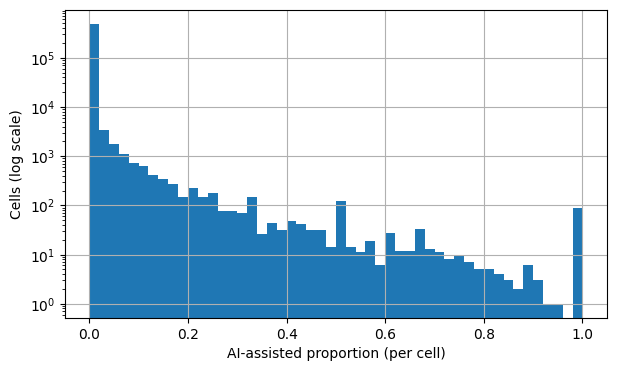

In [44]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
df_analysis['ai_assisted_proportion'].hist(bins=50, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('AI-assisted proportion (per cell)')
ax.set_ylabel('Cells (log scale)')
plt.show()

In [47]:
df_analysis = df_analysis.sort_values(['repo_id', 'month']).reset_index(drop=True)
df_analysis['cumulative_open_issues'] = (
    df_analysis.groupby('repo_id')['backlog_growth'].cumsum()
)
df_analysis['cumulative_external_open_issues'] = (
    df_analysis.groupby('repo_id')['external_backlog_growth'].cumsum()
)

In [48]:
df_analysis['cum_total_commits'] = (
    df_analysis.groupby('repo_id')['total_commits'].cumsum()
)
df_analysis['cum_ai_commits'] = (
    df_analysis.groupby('repo_id')['ai_assisted_commits'].cumsum()
)
df_analysis['cumulative_ai_share'] = np.where(
    df_analysis['cum_total_commits'] > 0,
    df_analysis['cum_ai_commits'] / df_analysis['cum_total_commits'],
    np.nan,
)

In [49]:
df_analysis['ai_assisted_proportion_lag1'] = (
    df_analysis.groupby('repo_id')['ai_assisted_proportion'].shift(1)
)
df_analysis['ai_assisted_proportion_lag2'] = (
    df_analysis.groupby('repo_id')['ai_assisted_proportion'].shift(2)
)

In [50]:
print(f"Final analysis sample: {len(df_analysis):,} cells, "
    f"{df_analysis['repo_id'].nunique():,} repos")
print(f"Months: {df_analysis['month'].min()} → {df_analysis['month'].max()}")
print(f"Cell-level AI rate: {(df_analysis['ai_assisted_commits'] > 0).mean():.2%}")
print(f"Repo-level AI rate: "
    f"{df_analysis.groupby('repo_id')['ai_assisted_commits'].sum().gt(0).mean():.2%}")
print("\nCells per repo distribution:")
print(df_analysis.groupby('repo_id').size().describe())

Final analysis sample: 509,711 cells, 65,452 repos
Months: 2024-09 → 2025-09
Cell-level AI rate: 3.45%
Repo-level AI rate: 12.30%

Cells per repo distribution:
count    65452.000000
mean         7.787554
std          4.324158
min          1.000000
25%          4.000000
50%          8.000000
75%         13.000000
max         13.000000
dtype: float64


In [53]:
df_analysis['has_ai'] = (df_analysis['ai_assisted_commits'] > 0).astype(int)
print(f"has_ai = 1: {df_analysis['has_ai'].mean():.2%} of cells")

has_ai = 1: 3.45% of cells


In [54]:
def winsorize(series, lower=0.01, upper=0.99):
    s = series.astype('float64')
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

for col in ['backlog_growth', 'external_backlog_growth',
            'closure_rate', 'external_closure_rate']:
    df_analysis[f'{col}_w'] = winsorize(df_analysis[col])

print(df_analysis[['backlog_growth', 'backlog_growth_w',
        'external_backlog_growth', 'external_backlog_growth_w']].describe())

       backlog_growth  backlog_growth_w  external_backlog_growth  \
count        509711.0     509711.000000                 509711.0   
mean         1.140407          1.137829                 1.101222   
std         18.798819          6.754870                18.707927   
min           -4231.0        -24.000000                  -4231.0   
25%              -1.0         -1.000000                     -1.0   
50%               0.0          0.000000                      0.0   
75%               3.0          3.000000                      2.0   
max            4270.0         32.000000                   4270.0   

       external_backlog_growth_w  
count              509711.000000  
mean                    1.095558  
std                     6.597916  
min                   -24.000000  
25%                    -1.000000  
50%                     0.000000  
75%                     2.000000  
max                    31.000000  


In [55]:
df_analysis['log_total_commits'] = np.log1p(df_analysis['total_commits'].astype('float64'))
df_analysis['log_stars_gained']  = np.log1p(df_analysis['stars_gained'].astype('float64'))

print(df_analysis[['total_commits', 'log_total_commits',
        'stars_gained', 'log_stars_gained']].describe())

       total_commits  log_total_commits  stars_gained  log_stars_gained
count       509711.0      509711.000000      509711.0     509711.000000
mean      130.208432           3.467018     30.382283          1.292914
std       585.014552           1.665828    275.313263          1.605444
min              0.0           0.000000           0.0          0.000000
25%              8.0           2.197225           0.0          0.000000
50%             31.0           3.465736           1.0          0.693147
75%            103.0           4.644391           8.0          2.197225
max          99836.0          11.511294       51244.0         10.844373


In [56]:
cells_per_repo = df_analysis.groupby('repo_id').size()
print(cells_per_repo.describe())
print(f"\nRepos with ≥2 cells (FE-eligible): "
    f"{(cells_per_repo >= 2).sum():,} of {len(cells_per_repo):,}")

count    65452.000000
mean         7.787554
std          4.324158
min          1.000000
25%          4.000000
50%          8.000000
75%         13.000000
max         13.000000
dtype: float64

Repos with ≥2 cells (FE-eligible): 62,014 of 65,452


In [57]:
reg_cols = [
    'backlog_growth_w', 'external_backlog_growth_w',
    'ai_assisted_proportion', 'has_ai',
    'ai_assisted_proportion_lag1', 'ai_assisted_proportion_lag2',
    'log_total_commits', 'unique_human_contributors', 'log_stars_gained',
    'cumulative_ai_share', 'cumulative_open_issues',
]
print(df_analysis[reg_cols].isna().sum())

backlog_growth_w                    0
external_backlog_growth_w           0
ai_assisted_proportion           7728
has_ai                              0
ai_assisted_proportion_lag1     71961
ai_assisted_proportion_lag2    132935
log_total_commits                   0
unique_human_contributors           0
log_stars_gained                    0
cumulative_ai_share               756
cumulative_open_issues              0
dtype: int64


In [59]:
before = len(df_analysis)
df_analysis = df_analysis[df_analysis['total_commits'] > 0].copy()
print(f"Dropped {before - len(df_analysis):,} bot-only cells "
    f"({(before - len(df_analysis))/before:.2%}). "
    f"Remaining: {len(df_analysis):,} cells, {df_analysis['repo_id'].nunique():,} repos")

Dropped 7,728 bot-only cells (1.52%). Remaining: 501,983 cells, 65,451 repos


# EDA

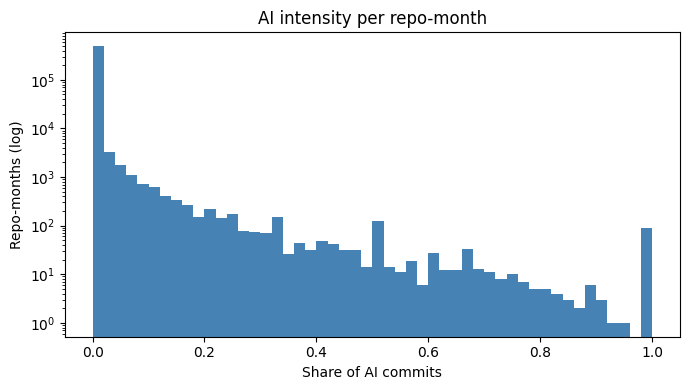

In [229]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df_analysis['ai_assisted_proportion'].dropna(), bins=50, color='steelblue')
ax.set_yscale('log')
ax.set_xlabel('Share of AI commits')
ax.set_ylabel('Repo-months (log)')
ax.set_title('AI intensity per repo-month')

plt.tight_layout()
plt.savefig('figures/ai_intensity_hist.png')
plt.show()

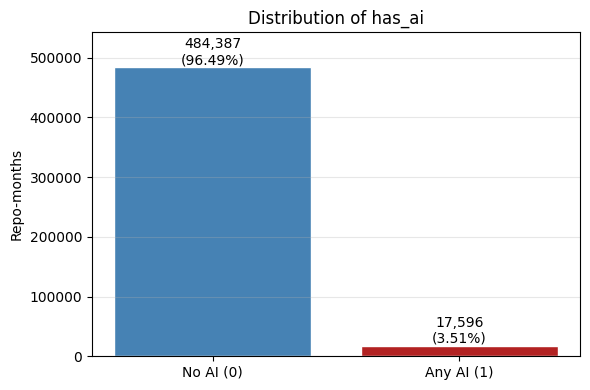

Total repo-months: 501,983
Cell-level AI rate: 3.51%


/var/folders/n4/xywlg4ts6kz33tbjld0x75pr0000gn/T/ipykernel_28653/1170294026.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Cell-level AI rate: {counts[1] / total:.2%}')


In [231]:
# === Bar plot: has_ai distribution at the cell level ===
counts = df_analysis['has_ai'].value_counts().sort_index()
labels = ['No AI (0)', 'Any AI (1)']
total  = counts.sum()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values,
            color=['steelblue', 'firebrick'], edgecolor='white')

# Annotate each bar with absolute count and percentage
for bar, n in zip(bars, counts.values):
    pct = n / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{n:,}\n({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10)
#ax.set_yscale('log')
ax.set_ylabel('Repo-months')
ax.set_title('Distribution of has_ai')
ax.set_ylim(0, counts.max() * 1.12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/has_ai_distribution.png')
plt.show()

print(f'Total repo-months: {total:,}')
print(f'Cell-level AI rate: {counts[1] / total:.2%}')

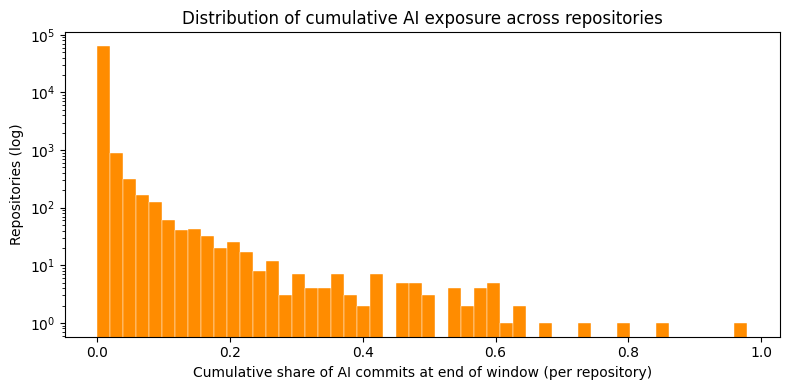

In [197]:
# === Distribution of cumulative_ai_share at window end (per repo) ===
repo_cum_ai = (
    df_analysis.sort_values(['repo_id', 'month'])
                .groupby('repo_id')['cumulative_ai_share'].last().dropna()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(repo_cum_ai, bins=50, color='darkorange',
        edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Cumulative share of AI commits at end of window (per repository)')
ax.set_ylabel('Repositories (log)')
ax.set_title('Distribution of cumulative AI exposure across repositories')
plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


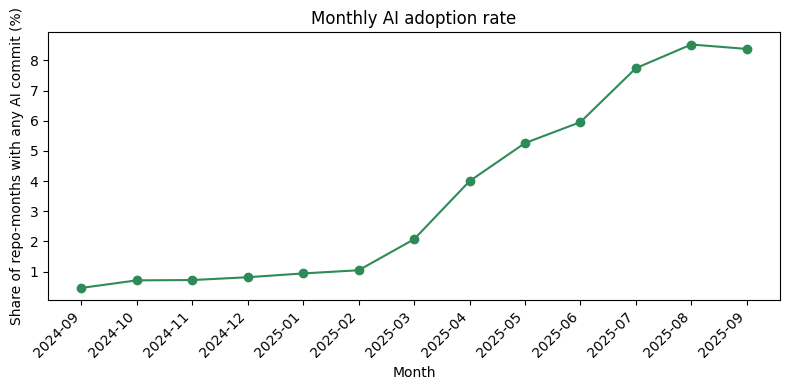

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

monthly = df_analysis.groupby('month')['has_ai'].mean().sort_index() * 100
monthly.index = pd.to_datetime(monthly.index + '-01')

releases = [
    ('2024-10-22', 'Claude 3.5 Sonnet (v2)'),
    ('2025-02-24', 'Claude 3.7 Sonnet + Claude Code'),
    ('2025-04-04', 'Copilot agent mode GA'),
    ('2025-05-22', 'Claude 4'),
    ('2025-08-05', 'Claude Opus 4.1'),
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker='o', color='seagreen', zorder=3)

for i, (date, label) in enumerate(releases):
    d = pd.to_datetime(date)
    ax.axvline(d, color='grey', linestyle='--', alpha=0.5, zorder=1)
    # stagger labels vertically so they don't overlap
    y = ax.get_ylim()[1] * (0.95 - (i % 3) * 0.12)
    ax.annotate(label, xy=(d, y), xytext=(4, 0), textcoords='offset points',
                rotation=0, fontsize=8, color='dimgrey',
                ha='left', va='top')

ax.set_xlabel('Month')
ax.set_ylabel('Share of repo-months with any AI commit (%)')
ax.set_title('Monthly AI adoption rate, with major model releases')
ax.grid(True, alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/monthly_ai_adoption_releases.png')
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

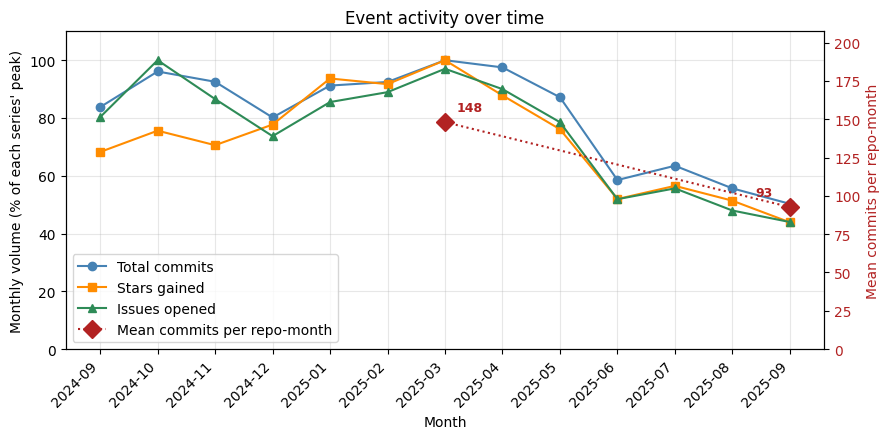

In [239]:
# === Event volumes + 2 reference points for mean commits per repo-month ===
monthly = (df_analysis.groupby('month')
            .agg(commits=('total_commits', 'sum'),
                stars=('stars_gained', 'sum'),
                issues=('issues_opened', 'sum'),
                mean_commits=('total_commits', 'mean'))
            .sort_index())

monthly_norm = (monthly[['commits', 'stars', 'issues']]
                / monthly[['commits', 'stars', 'issues']].max() * 100)

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.plot(monthly_norm.index, monthly_norm['commits'], marker='o',
        color='steelblue',  label='Total commits')
ax1.plot(monthly_norm.index, monthly_norm['stars'],   marker='s',
        color='darkorange', label='Stars gained')
ax1.plot(monthly_norm.index, monthly_norm['issues'],  marker='^',
        color='seagreen',   label='Issues opened')

ax1.set_xlabel('Month')
ax1.set_ylabel("Monthly volume (% of each series' peak)")
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Two reference points for mean commits per repo-month (absolute scale)
start_month, end_month = '2025-03', '2025-09'
start_val = monthly.loc[start_month, 'mean_commits']
end_val   = monthly.loc[end_month,   'mean_commits']

ax2 = ax1.twinx()
ax2.plot([start_month, end_month], [start_val, end_val],
        marker='D', color='firebrick', linestyle=':', markersize=9,
        label='Mean commits per repo-month')
ax2.set_ylabel('Mean commits per repo-month', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0, max(start_val, end_val) * 1.4)

# Label each point with its value
ax2.annotate(f'{start_val:.0f}', (start_month, start_val),
            textcoords='offset points', xytext=(8, 8),
            color='firebrick', fontsize=9, fontweight='bold')
ax2.annotate(f'{end_val:.0f}',   (end_month,   end_val),
            textcoords='offset points', xytext=(-25, 8),
            color='firebrick', fontsize=9, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

ax1.set_title('Event activity over time')
plt.tight_layout()
plt.savefig('figures/event_activity.png')
plt.show()

In [150]:
# Pick a few famously active repos and check their monthly trajectory directly
known_active = ['microsoft/vscode', 'apache/maven', 'rust-lang/rust',
                'kubernetes/kubernetes', 'tensorflow/tensorflow']
sanity = (df_analysis[df_analysis['repo_name'].isin(known_active)]
        .groupby(['repo_name', 'month'])['total_commits'].sum()
        .unstack('month'))
print(sanity)

month                  2024-09  2024-10  2024-11  2024-12  2025-01  2025-02  \
repo_name                                                                     
apache/maven               117      173       80       64       77       69   
kubernetes/kubernetes      767      875      677      332      508      523   
microsoft/vscode          4129     2767     3113     <NA>     2991     4709   
rust-lang/rust            1592     1743     1558     1582     1878     1640   
tensorflow/tensorflow      118      499       90        7       59       35   

month                  2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  \
repo_name                                                                     
apache/maven               197      189       87       50      146       52   
kubernetes/kubernetes      926      342      475      356      767      294   
microsoft/vscode          4036     5055     3520     1820     2963     2900   
rust-lang/rust            1521     1549     3157   

In [ ]:
# save plot to folder

plt.savefig('figures/figure1.png')

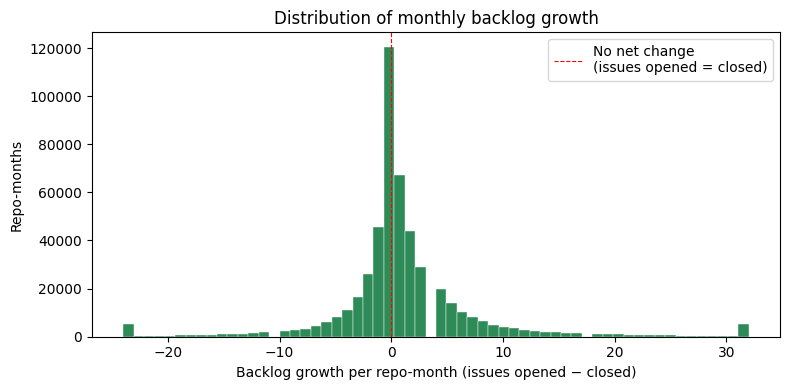

In [230]:
#ensure the folder exists
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_analysis['backlog_growth_w'], bins=60, color='seagreen',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', lw=0.8,
            label='No net change\n(issues opened = closed)')
ax.set_xlabel('Backlog growth per repo-month (issues opened − closed)')
ax.set_ylabel('Repo-months')
ax.set_title('Distribution of monthly backlog growth')
ax.legend()
plt.tight_layout()
plt.savefig('figures/backlog_growth_hist.png')
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


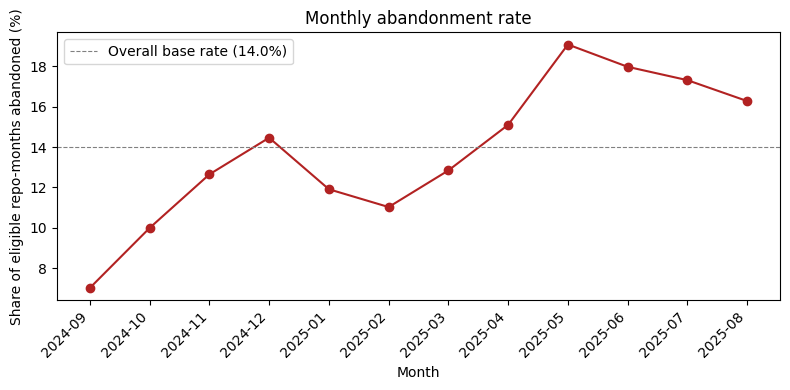

In [232]:
# Monthly abandonment rate (only for eligible cells)
abandonment_monthly = (
    df_analysis[df_analysis['abandonment_it'].notna()]
    .groupby('month')['abandonment_it'].mean().sort_index() * 100
)

# Overall base rate, computed from the same eligible sample
base_rate = df_analysis['abandonment_it'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(abandonment_monthly.index, abandonment_monthly.values,
        marker='o', color='firebrick')
ax.axhline(base_rate, color='grey', linestyle='--', lw=0.8,
            label=f'Overall base rate ({base_rate:.1f}%)')
ax.set_xlabel('Month')
ax.set_ylabel('Share of eligible repo-months abandoned (%)')
ax.set_title('Monthly abandonment rate')
ax.legend(loc='best')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/abandonment_rate.png')
plt.show()

In [193]:
df_analysis.shape

(501983, 39)

# Relationships

/var/folders/n4/xywlg4ts6kz33tbjld0x75pr0000gn/T/ipykernel_28653/4201254708.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No AI', 'Any AI'],


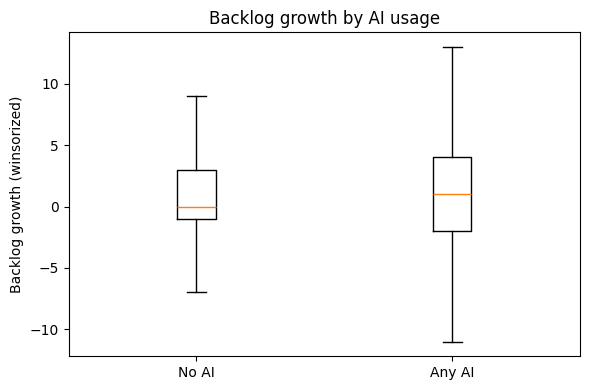

In [233]:
# === Plot 2: has_ai (binary) vs backlog growth — box plot ===
fig, ax = plt.subplots(figsize=(6, 4))
groups = [df_analysis.loc[df_analysis['has_ai'] == 0, 'backlog_growth_w'],
        df_analysis.loc[df_analysis['has_ai'] == 1, 'backlog_growth_w']]
ax.boxplot(groups, labels=['No AI', 'Any AI'],
            showfliers=False)
ax.set_ylabel('Backlog growth (winsorized)')
ax.set_title('Backlog growth by AI usage')
plt.tight_layout()
plt.savefig('figures/backlog_growth_box.png')
plt.show()

                     mean   count
No AI exposure   0.143823  283988
Any AI exposure  0.084785   18140


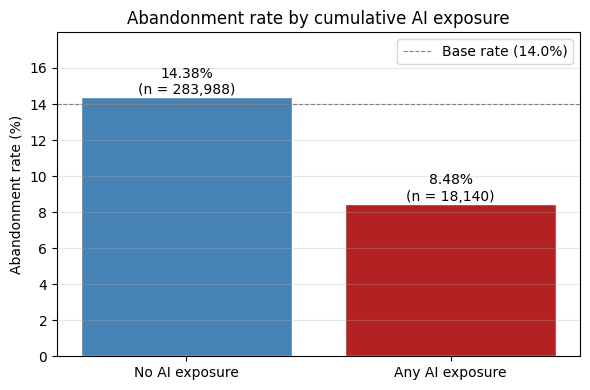

In [234]:
# === Two-group bar: abandonment rate by cumulative AI exposure (binary) ===
eligible = df_analysis[df_analysis['abandonment_it'].notna()].copy()
eligible['has_cum_ai'] = (eligible['cumulative_ai_share'] > 0).astype(int)

rates = eligible.groupby('has_cum_ai')['abandonment_it'].agg(['mean', 'count'])
rates.index = ['No AI exposure', 'Any AI exposure']
print(rates)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(rates.index, rates['mean'] * 100,
            color=['steelblue', 'firebrick'], edgecolor='white')
base = eligible['abandonment_it'].mean() * 100
ax.axhline(base, color='grey', linestyle='--', lw=0.8,
            label=f'Base rate ({base:.1f}%)')

for bar, (val, n) in zip(bars, zip(rates['mean'] * 100, rates['count'])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}%\n(n = {n:,})',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Abandonment rate (%)')
ax.set_title('Abandonment rate by cumulative AI exposure')
ax.set_ylim(0, max(rates['mean'] * 100) * 1.25)
ax.legend(loc='best')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/abandonment_rate_by_cumulative_ai.png')
plt.show()

    bucket      rate       n
0       0%  0.143754  284125
1   0–0.5%  0.050162    8632
2   0.5–2%  0.099022    5827
3     2–5%  0.125450    2224
4    5–10%  0.185786     802
5   10–25%  0.173127     387
6  25–100%  0.251908     131


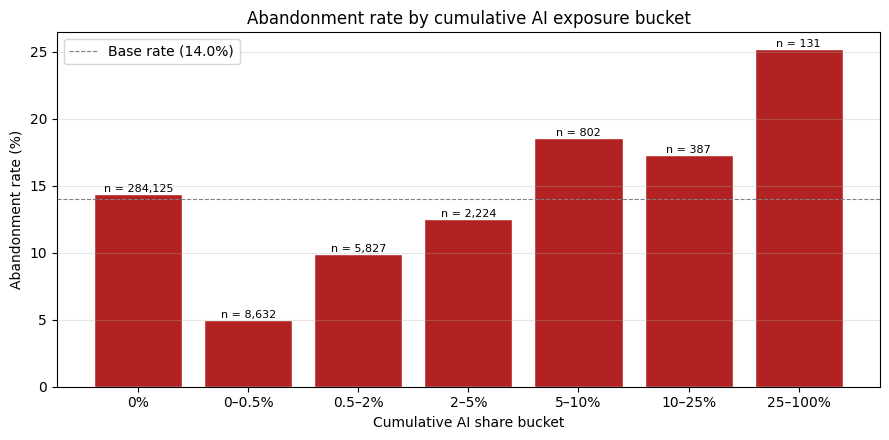

In [235]:
# === Multi-bucket bar: abandonment rate by cumulative AI bucket ===
eligible = df_analysis[df_analysis['abandonment_it'].notna()].copy()
cum_ai_bins = [-0.0001, 0.0001, 0.005, 0.02, 0.05, 0.10, 0.25, 1.0001]
bucket_labels = ['0%', '0–0.5%', '0.5–2%', '2–5%', '5–10%', '10–25%', '25–100%']

eligible['bucket'] = pd.cut(eligible['cumulative_ai_share'],
                            bins=cum_ai_bins, labels=bucket_labels,
                            include_lowest=True)

bucket_stats = (eligible.groupby('bucket', observed=True)['abandonment_it']
                .agg(rate='mean', n='count').reset_index())
print(bucket_stats)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(bucket_stats['bucket'].astype(str),
            bucket_stats['rate'] * 100, color='firebrick',
            edgecolor='white')
base = eligible['abandonment_it'].mean() * 100
ax.axhline(base, color='grey', linestyle='--', lw=0.8,
            label=f'Base rate ({base:.1f}%)')

for bar, n in zip(bars, bucket_stats['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'n = {n:,}', ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_xlabel('Cumulative AI share bucket')
ax.set_ylabel('Abandonment rate (%)')
ax.set_title('Abandonment rate by cumulative AI exposure bucket')
ax.legend(loc='best')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/abandonment_rate_by_cumulative_ai_bucket.png')
plt.show()

In [311]:
# === Summary statistics table for the Results chapter ===
def stats(series, label):
    s = series.dropna().astype('float64')
    return {
        'Variable': label,
        'N':       len(s),
        'Mean':    s.mean(),
        'SD':      s.std(),
        'Min':     s.min(),
        'p25':     s.quantile(0.25),
        'Median':  s.median(),
        'p75':     s.quantile(0.75),
        'Max':     s.max(),
    }

# Repo-level end-of-window views for the cumulative variables
repo_cum_ai = (df_analysis.sort_values(['repo_id', 'month'])
                        .groupby('repo_id')['cumulative_ai_share'].last())
repo_cum_issues = (df_analysis.sort_values(['repo_id', 'month'])
                            .groupby('repo_id')['cumulative_open_issues'].last())

rows = [
    # Treatment
    stats(df_analysis['ai_assisted_proportion'],   'ai_assisted_proportion (cell)'),
    stats(df_analysis['has_ai'],                   'has_ai (cell)'),
    stats(repo_cum_ai,                             'cumulative_ai_share (repo, end)'),
    # Outcomes
    stats(df_analysis['backlog_growth'],           'backlog_growth (raw)'),
    stats(df_analysis['backlog_growth_w'],         'backlog_growth (winsorized)'),
    stats(df_analysis.loc[df_analysis['abandonment_it'].notna(), 'abandonment_it'],
                                                    'abandonment_it (eligible cells)'),
    stats(repo_cum_issues,                         'cumulative_open_issues (repo, end)'),
    # Controls
    stats(df_analysis['total_commits'],            'total_commits'),
    stats(df_analysis['log_total_commits'],        'log_total_commits'),
    stats(df_analysis['unique_human_contributors'],'unique_human_contributors'),
    stats(df_analysis['stars_gained'],             'stars_gained'),
    stats(df_analysis['log_stars_gained'],         'log_stars_gained'),
]

summary = pd.DataFrame(rows).set_index('Variable').round(3)
print(summary.to_string())

# === Export as Markdown for direct paste into the dissertation ===
md = summary.to_markdown(floatfmt=',.3f')
print(md)

                                         N     Mean       SD       Min    p25  Median      p75        Max
Variable                                                                                                 
ai_assisted_proportion (cell)       501983    0.003    0.027     0.000  0.000   0.000    0.000      1.000
has_ai (cell)                       501983    0.035    0.184     0.000  0.000   0.000    0.000      1.000
cumulative_ai_share (repo, end)      65451    0.003    0.020     0.000  0.000   0.000    0.000      0.979
backlog_growth (raw)                501983    1.140   18.892 -4231.000 -1.000   0.000    3.000   4270.000
backlog_growth (winsorized)         501983    1.139    6.784   -24.000 -1.000   0.000    3.000     32.000
abandonment_it (eligible cells)     302128    0.140    0.347     0.000  0.000   0.000    0.000      1.000
cumulative_open_issues (repo, end)   65451    8.742   67.746 -4231.000 -1.000   5.000   14.000   4277.000
total_commits                       501983  13

# Regression

In [240]:
from pyfixest.estimation import feols
from pyfixest.report import etable

# Shared spec components
controls = "log_total_commits + unique_human_contributors + log_stars_gained"
fe       = "repo_id + month"
cluster  = {"CRV1": "repo_id"}

# === RQ1: Backlog growth ===
rq1_a = feols(f"backlog_growth_w ~ ai_assisted_proportion + {controls} | {fe}",
            data=df_analysis, vcov=cluster)
rq1_b = feols(f"backlog_growth_w ~ has_ai + {controls} | {fe}",
            data=df_analysis, vcov=cluster)
rq1_c = feols(f"backlog_growth_w ~ ai_assisted_proportion_lag1 + {controls} | {fe}",
            data=df_analysis, vcov=cluster)

# === RQ2: Abandonment (linear probability model) ===
rq2 = feols(f"abandonment_it ~ cumulative_ai_share + {controls} | {fe}",
            data=df_analysis, vcov=cluster)

# === Results table ===
etable([rq1_a, rq1_b, rq1_c, rq2])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 6679 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 8276 singleton fixed effect(s) dropped from the model.
  warnings.warn(


GT(_tbl_data=   __index_level_0__            __index_level_1__                    0  \
0               coef       ai_assisted_proportion  -0.456 <br> (0.311)   
1               coef            log_total_commits  -0.372 <br> (0.013)   
2               coef    unique_human_contributors   0.132 <br> (0.015)   
3               coef             log_stars_gained   0.864 <br> (0.023)   
4               coef                       has_ai                        
5               coef  ai_assisted_proportion_lag1                        
6               coef          cumulative_ai_share                        
7                 fe                        month                    x   
8                 fe                     repo_id                     x   
9              stats                 Observations              498,515   
10             stats                           R²                 0.24   

                      1                    2                       3  
0                                                                     
1   -0.371 <br> (0.013)  -0.381 <br> (0.013)  -0.044 <br> (0.000815)  
2    0.132 <br> (0.015)   0.111 <br> (0.017)   -0.005 <br> (0.00061)  
3    0.864 <br> (0.023)   0.621 <br> (0.025)     -0.014 <br> (0.001)  
4    -0.084 <br> (0.08)                                               
5                          -0.782 <br> (0.4)                          
6                                                -0.081 <br> (0.131)  
7                     x                    x                       x  
8                     x                    x                       x  
9               498,515              426,766                 293,852  
10                 0.24                0.262                   0.335  , _body=<great_tables._gt_data.Body object at 0x46e845f50>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x463fa6c10>, _spanners=Spanners([SpannerInfo(spanner_id='backlog_growth_w', spanner_level=1, spanner_label='backlog_growth_w', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2'], built=None), SpannerInfo(spanner_id='abandonment_it', spanner_level=1, spanner_label='abandonment_it', spanner_units=None, spanner_pattern=None, vars=['3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x46e414050>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x45c50ab90>, _source_notes=['Format of coefficient cell: Coefficient   (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x46e5657d0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='tab

In [289]:
for label, m in [("RQ1a", rq1_a), ("RQ1b", rq1_b), ("RQ1c", rq1_c), ("RQ2", rq2)]:
    print(f"\n=== {label} ===")
    print(m.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])


=== RQ1a ===
                           Estimate  Std. Error    t value  Pr(>|t|)
Coefficient                                                         
ai_assisted_proportion    -0.456183    0.310860  -1.467487  0.142249
log_total_commits         -0.371808    0.012704 -29.266832  0.000000
unique_human_contributors  0.131529    0.014847   8.859201  0.000000
log_stars_gained           0.864398    0.023397  36.945214  0.000000

=== RQ1b ===
                           Estimate  Std. Error    t value  Pr(>|t|)
Coefficient                                                         
has_ai                    -0.083750    0.080329  -1.042592  0.297141
log_total_commits         -0.370862    0.012735 -29.120620  0.000000
unique_human_contributors  0.131838    0.014858   8.873276  0.000000
log_stars_gained           0.864431    0.023396  36.948044  0.000000

=== RQ1c ===
                             Estimate  Std. Error    t value      Pr(>|t|)
Coefficient                                            

In [287]:
print(etable([rq1_a, rq1_b, rq1_c, rq2], type="tex", coef_fmt="b (se) sig"))

\begin{threeparttable}
\begingroup
\renewcommand\cellalign{t}
\renewcommand\arraystretch{1}
\setlength{\tabcolsep}{3pt}
\begin{tabularx}{\linewidth}{@{}>{\raggedright\arraybackslash}l>{\centering\arraybackslash}X>{\centering\arraybackslash}X>{\centering\arraybackslash}X>{\centering\arraybackslash}X}
\toprule
 & \multicolumn{3}{c}{backlog_growth_w} & \multicolumn{1}{c}{abandonment_it} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-5}
 & (1) & (2) & (3) & (4) \\
\midrule
\addlinespace[1ex]
ai_assisted_proportion & -0.456 (0.311) sig &  &  &  \\
\addlinespace[0.5ex]
\addlinespace[0.5ex]
log_total_commits & -0.372 (0.013) sig & -0.371 (0.013) sig & -0.381 (0.013) sig & -0.044 (0.000815) sig \\
\addlinespace[0.5ex]
\addlinespace[0.5ex]
unique_human_contributors & 0.132 (0.015) sig & 0.132 (0.015) sig & 0.111 (0.017) sig & -0.005 (0.00061) sig \\
\addlinespace[0.5ex]
\addlinespace[0.5ex]
log_stars_gained & 0.864 (0.023) sig & 0.864 (0.023) sig & 0.621 (0.025) sig & -0.014 (0.001) sig \\
\addlinespace

# Model Diagnostics

In [260]:
import numpy as np

resid  = rq1_a.resid()    # numpy array
fitted = rq1_a.predict()  # numpy array

rng = np.random.default_rng(42)
idx = rng.choice(len(resid), 500, replace=False)

# Linearity

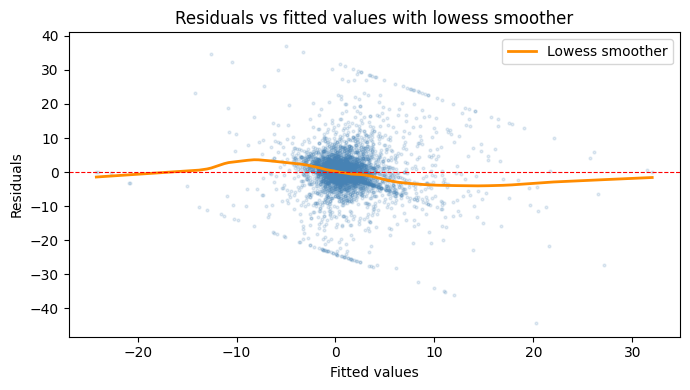

In [270]:
from statsmodels.nonparametric.smoothers_lowess import lowess

sample_idx = rng.choice(len(resid), 5000, replace=False)
smooth = lowess(resid[sample_idx], fitted[sample_idx], frac=0.3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(fitted[sample_idx], resid[sample_idx],
            alpha=0.15, s=4, color='steelblue')
ax.plot(smooth[:, 0], smooth[:, 1], color='darkorange', lw=2,
        label='Lowess smoother')
ax.axhline(0, color='red', linestyle='--', lw=0.8)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs fitted values with lowess smoother')
ax.legend()
plt.tight_layout()
plt.savefig('figures/diag_linearity.png')
plt.show()

# Random Sampling (text)

# Multicollinearity

                    Variable       VIF
0     ai_assisted_proportion  1.000098
1          log_total_commits  1.200538
2  unique_human_contributors  1.202324
3           log_stars_gained  1.019070


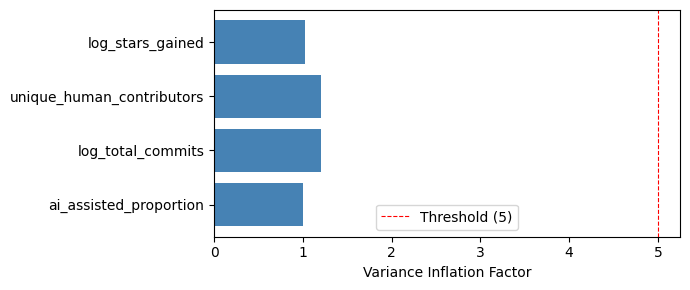

In [272]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import matplotlib.pyplot as plt

X = (df_analysis[['ai_assisted_proportion', 'log_total_commits',
                'unique_human_contributors', 'log_stars_gained']]
    .dropna()
    .astype('float64'))

# add_constant ensures VIFs are computed in the standard way
X_with_const = add_constant(X)

vif = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X_with_const.values, i + 1)
            for i in range(X.shape[1])]
})
print(vif)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(vif['Variable'], vif['VIF'], color='steelblue')
ax.axvline(5, color='red', linestyle='--', lw=0.8, label='Threshold (5)')
ax.set_xlabel('Variance Inflation Factor')
ax.legend()
plt.tight_layout()
plt.savefig('figures/diag_vif.png')
plt.show()

In [276]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

reg_cols = ['ai_assisted_proportion', 'log_total_commits',
            'unique_human_contributors', 'log_stars_gained']
sample = (df_analysis[reg_cols + ['backlog_growth_w', 'repo_id']]
        .dropna().reset_index(drop=True))

counts = sample.groupby('repo_id')['repo_id'].transform('size')
sample = sample[counts >= 2].reset_index(drop=True)

assert len(sample) == len(resid), \
    f"Length mismatch: sample={len(sample):,}, resid={len(resid):,}"

X = add_constant(sample[reg_cols].astype('float64').values)

lm_stat, lm_p, f_stat, f_p = het_breuschpagan(resid, X)

print(f"Breusch–Pagan test (Koenker / studentized):")
print(f"  LM statistic:       {lm_stat:,.2f}")
print(f"  Degrees of freedom: {X.shape[1] - 1}")   # don't count the constant
print(f"  P-value:            {lm_p:.3e}")

Breusch–Pagan test (Koenker / studentized):
  LM statistic:       29,026.27
  Degrees of freedom: 4
  P-value:            0.000e+00


In [277]:
from scipy.stats import shapiro
import numpy as np

# Shapiro–Wilk on a subsample (scipy limits to N = 5,000)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(resid), 5000, replace=False)
sw_stat, sw_p = shapiro(resid[sample_idx])

print(f"Shapiro–Wilk test (subsample of 5,000):")
print(f"  W statistic: {sw_stat:.4f}")
print(f"  P-value:     {sw_p:.3e}")

Shapiro–Wilk test (subsample of 5,000):
  W statistic: 0.8471
  P-value:     1.269e-56


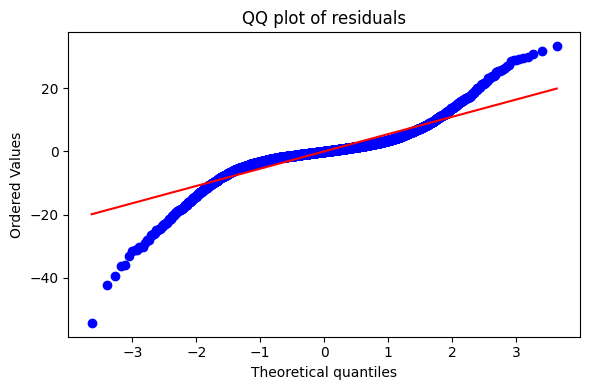

In [283]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(6, 4))
sample_idx = rng.choice(len(resid), 5000, replace=False)
sample = resid[sample_idx]
stats.probplot(sample, dist='norm', plot=ax)
ax.set_title('QQ plot of residuals')
plt.tight_layout()
plt.savefig('figures/diag_normality.png')
plt.show()

# Robustness

In [290]:
df_analysis.columns

Index(['repo_id', 'month', 'repo_name', 'total_commits', 'ai_assisted_commits',
       'unique_human_contributors', 'stars_gained', 'issues_opened',
       'issues_closed', 'external_issues_opened', 'external_issues_closed',
       'backlog_growth', 'external_backlog_growth', 'any_closure',
       'closure_rate', 'external_closure_rate', 'window_total_commits',
       'window_unique_contributors', 'window_external_issues_opened_total',
       'ai_assisted_proportion', 'cumulative_open_issues',
       'cumulative_external_open_issues', 'cum_total_commits',
       'cum_ai_commits', 'cumulative_ai_share', 'ai_assisted_proportion_lag1',
       'ai_assisted_proportion_lag2', 'has_ai', 'backlog_growth_w',
       'external_backlog_growth_w', 'closure_rate_w',
       'external_closure_rate_w', 'log_total_commits', 'log_stars_gained',
       'ai_bucket', 'month_dt', 'next_month_dt', 'has_next_month',
       'abandonment_it'],
      dtype='object')

In [304]:
#check byte size of df

import sys
size_bytes = sys.getsizeof(df)
size_mb = size_bytes / (1024 * 1024)
print(f"DataFrame size: {size_mb:.2f} MB")

DataFrame size: 198.39 MB


In [ ]:
# 1. Active repos
active = df_analysis[df_analysis['window_total_commits'] >= 100]
rob_1 = feols(f"backlog_growth_w ~ ai_assisted_proportion + {controls} | {fe}",
            data=active, vcov=cluster)

# 2. Tighter threshold
df_analysis['has_ai_strict'] = (df_analysis['ai_assisted_commits'] >= 3).astype(int)
rob_2 = feols(f"backlog_growth_w ~ has_ai_strict + {controls} | {fe}",
            data=df_analysis, vcov=cluster)

# 3. Drop top 1%
cutoff = df_analysis.groupby('repo_id')['total_commits'].sum().quantile(0.99)
trimmed_ids = df_analysis.groupby('repo_id')['total_commits'].sum().loc[lambda s: s <= cutoff].index
trimmed = df_analysis[df_analysis['repo_id'].isin(trimmed_ids)]
rob_3 = feols(f"backlog_growth_w ~ ai_assisted_proportion + {controls} | {fe}",
            data=trimmed, vcov=cluster)

# 4. Two-way clustered SE
rob_4 = feols(f"backlog_growth_w ~ ai_assisted_proportion + {controls} | {fe}",
            data=df_analysis,
            vcov={"CRV1": "repo_id + month"})

In [298]:
#distribution of ai assisted commits in active df
print(active['ai_assisted_commits'].describe())

count    434344.0
mean     0.412337
std      9.242185
min           0.0
25%           0.0
50%           0.0
75%           0.0
max        2169.0
Name: ai_assisted_commits, dtype: Float64


In [293]:
rob_4 = feols(f"backlog_growth_w ~ ai_assisted_proportion + {controls} | {fe}",
            data=df_analysis,
            vcov={"CRV1": "repo_id + month"})

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [295]:
for label, m in [("rob1", rob_1), ("rob2", rob_2), ("rob3", rob_3), ("rob4", rob_4)]:
    print(f"\n=== {label} ===")
    print(m.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])


=== rob1 ===
                           Estimate  Std. Error    t value  Pr(>|t|)
Coefficient                                                         
ai_assisted_proportion    -0.371179    0.356511  -1.041141  0.297815
log_total_commits         -0.390204    0.013307 -29.323634  0.000000
unique_human_contributors  0.131649    0.015192   8.665522  0.000000
log_stars_gained           0.846191    0.025539  33.132956  0.000000

=== rob2 ===
                           Estimate  Std. Error    t value  Pr(>|t|)
Coefficient                                                         
has_ai_strict             -0.164906    0.117637  -1.401822  0.160973
log_total_commits         -0.370449    0.012738 -29.082789  0.000000
unique_human_contributors  0.131964    0.014849   8.887006  0.000000
log_stars_gained           0.864391    0.023396  36.946457  0.000000

=== rob3 ===
                           Estimate  Std. Error    t value  Pr(>|t|)
Coefficient                                                  

In [292]:
# === Results table ===
etable([rob_1, rob_2, rob_3])

GT(_tbl_data=  __index_level_0__          __index_level_1__                    0  \
0              coef     ai_assisted_proportion  -0.371 <br> (0.357)   
1              coef          log_total_commits   -0.39 <br> (0.013)   
2              coef  unique_human_contributors   0.132 <br> (0.015)   
3              coef           log_stars_gained   0.846 <br> (0.026)   
4              coef              has_ai_strict                        
5                fe                      month                    x   
6                fe                   repo_id                     x   
7             stats               Observations              432,242   
8             stats                         R²                0.229   

                     1                    2  
0                       -0.477 <br> (0.302)  
1   -0.37 <br> (0.013)  -0.386 <br> (0.012)  
2   0.132 <br> (0.015)   0.163 <br> (0.012)  
3   0.864 <br> (0.023)   0.857 <br> (0.023)  
4  -0.165 <br> (0.118)                       
5                    x                    x  
6                    x                    x  
7              498,515              490,202  
8                 0.24                0.233  , _body=<great_tables._gt_data.Body object at 0x4a6f36ad0>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x48f08fa90>, _spanners=Spanners([SpannerInfo(spanner_id='backlog_growth_w', spanner_level=1, spanner_label='backlog_growth_w', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x487aa05d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4a6e8e310>, _source_notes=['Format of coefficient cell: Coefficient   (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4a6e8cd50>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_includ

In [296]:
rob_rq2_1 = feols(f"abandonment_it ~ cumulative_ai_share + {controls} | {fe}",
                data=active, vcov=cluster)

# 2. Tighter AI exposure threshold (sustained, non-incidental use)
df_analysis['cumulative_ai_strict'] = (df_analysis['cumulative_ai_share'] >= 0.01).astype(int)
rob_rq2_2 = feols(f"abandonment_it ~ cumulative_ai_strict + {controls} | {fe}",
                data=df_analysis, vcov=cluster)

# 3. Drop top 1% by commit volume
cutoff = df_analysis.groupby('repo_id')['total_commits'].sum().quantile(0.99)
trimmed_ids = (df_analysis.groupby('repo_id')['total_commits'].sum()
                .loc[lambda s: s <= cutoff].index)
trimmed = df_analysis[df_analysis['repo_id'].isin(trimmed_ids)]
rob_rq2_3 = feols(f"abandonment_it ~ cumulative_ai_share + {controls} | {fe}",
                data=trimmed, vcov=cluster)

# 4. Two-way clustered SE (repo + month)
rob_rq2_4 = feols(f"abandonment_it ~ cumulative_ai_share + {controls} | {fe}",
                data=df_analysis, vcov={"CRV1": "repo_id + month"})

# Print results
for label, m in [("rq2_rob1", rob_rq2_1), ("rq2_rob2", rob_rq2_2),
                ("rq2_rob3", rob_rq2_3), ("rq2_rob4", rob_rq2_4)]:
    print(f"\n=== {label} ===")
    print(m.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 6079 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 8276 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 8240 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 8276 singleton fixed effect(s) dropped from the model.
  warnings.warn(



=== rq2_rob1 ===
                           Estimate  Std. Error    t value      Pr(>|t|)
Coefficient                                                             
cumulative_ai_share       -0.040171    0.134983  -0.297601  7.660090e-01
log_total_commits         -0.043223    0.000822 -52.575287  0.000000e+00
unique_human_contributors -0.004551    0.000590  -7.708016  1.310063e-14
log_stars_gained          -0.009944    0.001166  -8.527789  0.000000e+00

=== rq2_rob2 ===
                           Estimate  Std. Error    t value      Pr(>|t|)
Coefficient                                                             
cumulative_ai_strict       0.003378    0.006290   0.537016  5.912589e-01
log_total_commits         -0.044376    0.000815 -54.449118  0.000000e+00
unique_human_contributors -0.004883    0.000610  -8.009003  1.110223e-15
log_stars_gained          -0.013972    0.001223 -11.424386  0.000000e+00

=== rq2_rob3 ===
                           Estimate  Std. Error    t value  Pr(>|t|)
C

In [ ]:
# log of (1 + issues closed) -- closure as throughput signal
df_analysis['log_issues_closed'] = np.log1p(df_analysis['issues_closed'])

throughput = feols(f"log_issues_closed ~ ai_assisted_proportion + {controls} | {fe}",
                    data=df_analysis, vcov=cluster)
print(throughput.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])

Index(['repo_id', 'month', 'repo_name', 'total_commits', 'ai_assisted_commits',
       'unique_human_contributors', 'stars_gained', 'issues_opened',
       'issues_closed', 'external_issues_opened', 'external_issues_closed',
       'backlog_growth', 'external_backlog_growth', 'any_closure',
       'closure_rate', 'external_closure_rate', 'window_total_commits',
       'window_unique_contributors', 'window_external_issues_opened_total',
       'ai_assisted_proportion', 'cumulative_open_issues',
       'cumulative_external_open_issues', 'cum_total_commits',
       'cum_ai_commits', 'cumulative_ai_share', 'ai_assisted_proportion_lag1',
       'ai_assisted_proportion_lag2', 'has_ai', 'backlog_growth_w',
       'external_backlog_growth_w', 'closure_rate_w',
       'external_closure_rate_w', 'log_total_commits', 'log_stars_gained',
       'ai_bucket', 'month_dt', 'next_month_dt', 'has_next_month',
       'abandonment_it', 'has_ai_strict', 'cumulative_ai_strict'],
      dtype='object')

In [300]:
throughput = feols(f"issues_closed ~ ai_assisted_proportion + {controls} | {fe}",
                    data=df_analysis, vcov=cluster)
print(throughput.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(


                           Estimate  Std. Error    t value      Pr(>|t|)
Coefficient                                                             
ai_assisted_proportion     1.301050    1.023368   1.271341  2.036121e-01
log_total_commits          2.940911    0.063928  46.003626  0.000000e+00
unique_human_contributors  0.594233    0.105363   5.639856  1.709309e-08
log_stars_gained           1.990778    0.113445  17.548339  0.000000e+00


In [301]:
# log of (1 + issues closed) -- closure as throughput signal
df_analysis['log_issues_closed'] = np.log1p(df_analysis['issues_closed'])

throughput = feols(f"log_issues_closed ~ ai_assisted_proportion + {controls} | {fe}",
                    data=df_analysis, vcov=cluster)
print(throughput.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(


                           Estimate  Std. Error     t value      Pr(>|t|)
Coefficient                                                              
ai_assisted_proportion     0.273091    0.052304    5.221248  1.782931e-07
log_total_commits          0.390406    0.001967  198.510817  0.000000e+00
unique_human_contributors  0.028873    0.002562   11.269292  0.000000e+00
log_stars_gained           0.141853    0.002737   51.822601  0.000000e+00


In [302]:
df_analysis['log_issues_opened'] = np.log1p(df_analysis['issues_opened'])
opens = feols(f"log_issues_opened ~ ai_assisted_proportion + {controls} | {fe}",
            data=df_analysis, vcov=cluster)
print(opens.tidy()[["Estimate", "Std. Error", "t value", "Pr(>|t|)"]])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 3468 singleton fixed effect(s) dropped from the model.
  warnings.warn(


                           Estimate  Std. Error     t value  Pr(>|t|)
Coefficient                                                          
ai_assisted_proportion     0.145040    0.050951    2.846678  0.004419
log_total_commits          0.306692    0.002202  139.293448  0.000000
unique_human_contributors  0.039710    0.003018   13.158076  0.000000
log_stars_gained           0.203408    0.002918   69.701785  0.000000
